In [1]:
import pandas as pd   # for loading and working with tabular data
import numpy as np    # for numerical operations
import matplotlib.pyplot as plt  # for plotting graphs

# train/test splitting
from sklearn.model_selection import train_test_split

# tools to apply different preprocessing to numeric vs categorical columns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# tools for filling in missing values
from sklearn.impute import SimpleImputer

# turns text/categorical columns into numeric columns the model can use
from sklearn.preprocessing import OneHotEncoder

# model evaluation metrics
from sklearn.metrics import (
    classification_report,      # gives precision, recall, f1-score
    confusion_matrix,           # shows TP, TN, FP, FN counts
    roc_auc_score,              # ROC AUC score
    average_precision_score,    # PR AUC score
    precision_recall_curve,     # values for PR curve
    roc_curve                   # values for ROC curve
)

# first baseline model
from sklearn.linear_model import LogisticRegression

In [2]:
# Load the training transaction file
train_trans = pd.read_csv("../data/raw/train_transaction.csv")

# Load the training identity file
train_id = pd.read_csv("../data/raw/train_identity.csv")

# Merge them on TransactionID so each transaction gets matching identity info
# how="left" means keep every transaction, even if identity info is missing
df = train_trans.merge(train_id, on="TransactionID", how="left")

# Print the final merged shape
print(df.shape)

# Show the first few rows
df.head()

(590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [3]:
# y is the target we are trying to predict
# isFraud = 0 means non-fraud, 1 means fraud
y = df["isFraud"]

# These columns should not be used as model features
# isFraud is the answer column, so using it would leak the answer
# TransactionID is just an identifier, not a meaningful predictor
drop_cols = ["isFraud", "TransactionID"]

# X contains all the input features the model will learn from
X = df.drop(columns=drop_cols)

# Print shapes so we know our split between X and y is correct
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (590540, 432)
y shape: (590540,)


In [4]:
# Find the fraction of missing values in each feature column
missing_pct = X.isnull().mean()

# Identify columns where more than 90% of values are missing
# These columns usually add more noise than value, so we remove them
high_missing_cols = missing_pct[missing_pct > 0.90].index.tolist()

# Print how many columns are being dropped
print("Dropping", len(high_missing_cols), "columns with >90% missing values")

# Drop those very-high-missing columns
X = X.drop(columns=high_missing_cols)

# Check the new shape after dropping them
print("New X shape:", X.shape)

Dropping 12 columns with >90% missing values
New X shape: (590540, 420)


In [5]:
# Get a list of all numeric feature columns
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

# Get a list of all categorical/text feature columns
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

# Print counts for both types
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 391
Categorical features: 29


C:\Users\hariv\AppData\Local\Temp\ipykernel_11824\838731934.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


In [6]:
# Split the data into training and validation sets
# test_size=0.2 means 80% train, 20% validation
# stratify=y keeps the fraud percentage similar in both sets
# random_state makes results reproducible
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Print the shapes of the split datasets
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

# Print fraud rates to confirm stratification worked
print("Fraud rate train:", y_train.mean())
print("Fraud rate val:", y_val.mean())

X_train: (472432, 420)
X_val: (118108, 420)
Fraud rate train: 0.03498916246147594
Fraud rate val: 0.0349933958749619


In [8]:
# Numeric preprocessing:
# Fill missing numeric values with the median of that column
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing:
# 1. Fill missing text values with the most common category
# 2. One-hot encode categories into numeric columns
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Apply numeric preprocessing to numeric columns
# Apply categorical preprocessing to categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [9]:
# Build one pipeline that:
# 1. preprocesses the raw data
# 2. trains a logistic regression model
#
# class_weight="balanced" tells the model to pay more attention
# to the rare fraud class because the dataset is highly imbalanced
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

In [10]:
# Fit the pipeline on the training data
# This means:
# - fill missing numeric values
# - fill missing categorical values
# - one-hot encode categorical columns
# - train the logistic regression model
baseline_model.fit(X_train, y_train)

c:\Users\hariv\OneDrive\Desktop\Fraud Detection Platform\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [11]:
# Predict the fraud class (0 or 1) on the validation set
y_pred = baseline_model.predict(X_val)

# Predict fraud probabilities instead of just labels
# [:, 1] means take the probability for class 1 = fraud
y_proba = baseline_model.predict_proba(X_val)[:, 1]

In [12]:
# Print the classification report
# This shows precision, recall, and F1-score for each class
print("Classification Report:")
print(classification_report(y_val, y_pred))

# ROC AUC measures how well the model ranks fraud above non-fraud
print("ROC AUC:", roc_auc_score(y_val, y_proba))

# PR AUC is especially important for fraud because the data is imbalanced
print("PR AUC:", average_precision_score(y_val, y_proba))

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.66      0.79    113975
           1       0.07      0.67      0.12      4133

    accuracy                           0.67    118108
   macro avg       0.53      0.67      0.46    118108
weighted avg       0.95      0.67      0.77    118108

ROC AUC: 0.7443449247591079
PR AUC: 0.1324562769679235


In [13]:
# Confusion matrix shows:
# [[true negatives, false positives],
#  [false negatives, true positives]]
cm = confusion_matrix(y_val, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[75774 38201]
 [ 1358  2775]]


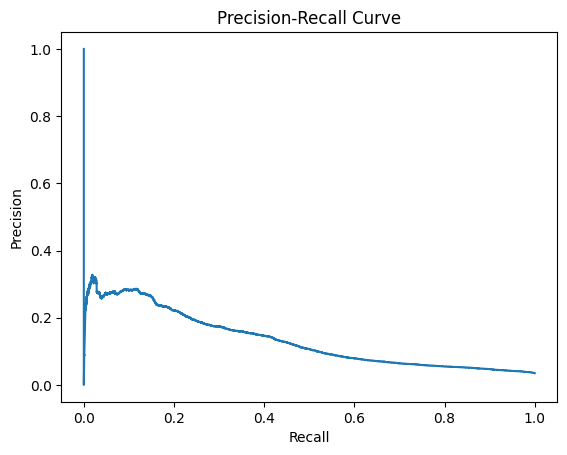

In [14]:
# Compute values needed to draw the precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_val, y_proba)

# Plot precision vs recall
plt.plot(recall, precision)

# Add labels and title
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

# Show the graph
plt.show()

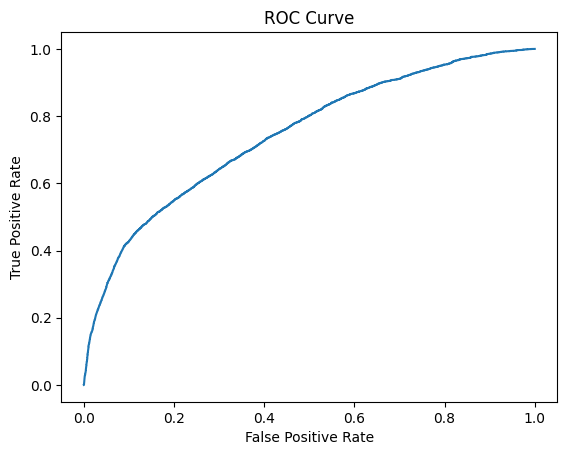

In [15]:
# Compute values needed to draw the ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_val, y_proba)

# Plot false positive rate vs true positive rate
plt.plot(fpr, tpr)

# Add labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

# Show the graph
plt.show()

In [16]:
# Count how many fraud predictions the model made
print("Predicted frauds:", y_pred.sum())

# Count how many actual frauds are in validation
print("Actual frauds in validation:", y_val.sum())

# Print average predicted fraud probability
print("Average predicted fraud probability:", y_proba.mean())

Predicted frauds: 40976
Actual frauds in validation: 4133
Average predicted fraud probability: 0.42049114639577917


## Baseline Model Notes

- Built a first baseline fraud classifier using logistic regression.
- Combined transaction and identity data, removed ID columns, and dropped features with more than 90% missing values.
- Imputed missing numeric values with the median and missing categorical values with the most frequent category.
- One-hot encoded categorical features so the model could use them.
- Used class weighting to account for the severe class imbalance in the fraud target.
- Evaluated the model using precision, recall, F1-score, ROC AUC, and PR AUC instead of accuracy alone.
- The baseline model achieved moderate fraud recall but produced a large number of false positives, making precision very low.
- This established a benchmark to improve with stronger tree-based models such as XGBoost.